# Geophysics Workshop for Baltic Precambrian Geologists

Arbavere, Estonia. 28.05.2026

**The aim:** estimate the amount of iron ore in the Inčukalns deposit.

**The outline:**
1. General information on the Inčukalns magnetic anomaly in Central Latvia
2. Magnetic data processing
3. Modelling the ore body

*Disclaimer: parts of the script were created using Claude AI.*

## About the Inčukalns magnetic anomaly

- Discovery
- Old aeromag data
- Geological data - sedimentary cover, borehole, borehole geophysics

## Magnetic data processing

- Data import
- Removal of outlier values
- Plot on map
- Diurnal correction
- Data decimation
- IGRF removal
- Regional trend removal
- Fit a straight line to data points and interpolate mag data

### **Workspace preparation and data import**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyproj
from sklearn.decomposition import PCA

In [2]:
# Read in the base station data
base = pd.read_csv("../data/base.txt",
                        delimiter=" ",
                        header=None,
                        usecols=[4, 6],
                        names=["time", "nT"]
                        )[10:-10] # Removing first and last values which are noisy due to mag setup operations
# Subtract first value from others to get the difference. Divide by 10 because Geometrics G856 doesnt write the comma.
base["nT"] = (base["nT"] - base["nT"].values[0]) / 10 
# Convert time values to `datetime` for formatting
base["time"] = pd.to_datetime(base["time"], format="%H%M%S")

# Read in the rover1 data
rover1 = pd.read_csv("../data/rover1.txt",
                        delimiter=" ",
                        skiprows=12,
                        # header=None,
                        usecols=[1, 3, 7, 13],
                        names=["latitude", "longitude", "nT", "time"]
                        ) # Removing first and last values which are noisy due to mag setup operations
# Remove rows that denote next waypoint line, which is characteristic for GEM magnetometers
rover1 = rover1[~rover1["latitude"].astype(str).str.startswith("line")]
# Remove some faulty rows
rover1 = rover1[~rover1["time"].astype(str).str.contains(r"\*")]
# Remove additional rows with faulty coordinates
rover1 = rover1[rover1["latitude"] != 0]
# Convert time values to `datetime` for formatting
rover1["time"] = pd.to_datetime(rover1["time"], format="%H%M%S.%f")


# Read in the rover2 data
rover2 = pd.read_csv("../data/rover2.txt",
                        delimiter=" ",
                        skiprows=12,
                        # header=None,
                        usecols=[1, 3, 7, 13],
                        names=["latitude", "longitude", "nT", "time"]
                        ) # Removing first and last values which are noisy due to mag setup operations
# Remove rows that denote next waypoint line, which is characteristic for GEM magnetometers
rover2 = rover2[~rover2["latitude"].astype(str).str.startswith("line")]
# Remove some faulty rows
rover2 = rover2[~rover2["time"].astype(str).str.contains(r"\*")]
# Remove additional rows with faulty coordinates
rover2 = rover2[rover2["latitude"] != 0]
# Convert time values to `datetime` for formatting
rover2["time"] = pd.to_datetime(rover2["time"], format="%H%M%S.%f")

Preview the added `base` dataset.

In [3]:
base

,time,nT
10,1900-01-01 07:07:03,0.0
11,1900-01-01 07:07:33,-1.0
12,1900-01-01 07:08:03,-0.6
13,1900-01-01 07:08:33,0.2
14,1900-01-01 07:09:03,-0.4
...,...,...
694,1900-01-01 12:49:03,2.6
695,1900-01-01 12:49:33,1.4
696,1900-01-01 12:50:03,1.0
697,1900-01-01 12:50:33,0.2


Preview the added `rover1` dataset.

In [4]:
rover1

,latitude,longitude,nT,time
0,57.020756,24.622227,52080.65,1900-01-01 07:53:40
1,57.020756,24.622226,52083.46,1900-01-01 07:53:42
2,57.020756,24.622226,52080.73,1900-01-01 07:53:44
3,57.020758,24.622228,52082.08,1900-01-01 07:53:46
4,57.020759,24.622241,52079.67,1900-01-01 07:53:48
...,...,...,...,...
3178,57.047382,24.646595,53149.76,1900-01-01 10:51:08
3179,57.047378,24.646594,53150.15,1900-01-01 10:51:10
3180,57.047376,24.646613,53149.75,1900-01-01 10:51:12
3181,57.047382,24.646605,53150.00,1900-01-01 10:51:14


### **Reproject coordinates to local coordinate system**

In [5]:
transformer = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326",
    crs_to="EPSG:3059",
    always_xy=True
)

rover1["x"], rover1["y"] = (
    np.array(v).round(0) 
    for v in transformer.transform(rover1["longitude"].values, rover1["latitude"].values)
)

rover2["x"], rover2["y"] = (
    np.array(v).round(0) 
    for v in transformer.transform(rover2["longitude"].values, rover2["latitude"].values)
)

View the added `x` and `y` columns.

In [6]:
rover1

,latitude,longitude,nT,time,x,y
0,57.020756,24.622227,52080.65,1900-01-01 07:53:40,537778.0,319869.0
1,57.020756,24.622226,52083.46,1900-01-01 07:53:42,537778.0,319869.0
2,57.020756,24.622226,52080.73,1900-01-01 07:53:44,537778.0,319868.0
3,57.020758,24.622228,52082.08,1900-01-01 07:53:46,537778.0,319869.0
4,57.020759,24.622241,52079.67,1900-01-01 07:53:48,537778.0,319869.0
...,...,...,...,...,...,...
3178,57.047382,24.646595,53149.76,1900-01-01 10:51:08,539229.0,322846.0
3179,57.047378,24.646594,53150.15,1900-01-01 10:51:10,539229.0,322846.0
3180,57.047376,24.646613,53149.75,1900-01-01 10:51:12,539230.0,322845.0
3181,57.047382,24.646605,53150.00,1900-01-01 10:51:14,539230.0,322846.0


### **Plot base and rover readings**

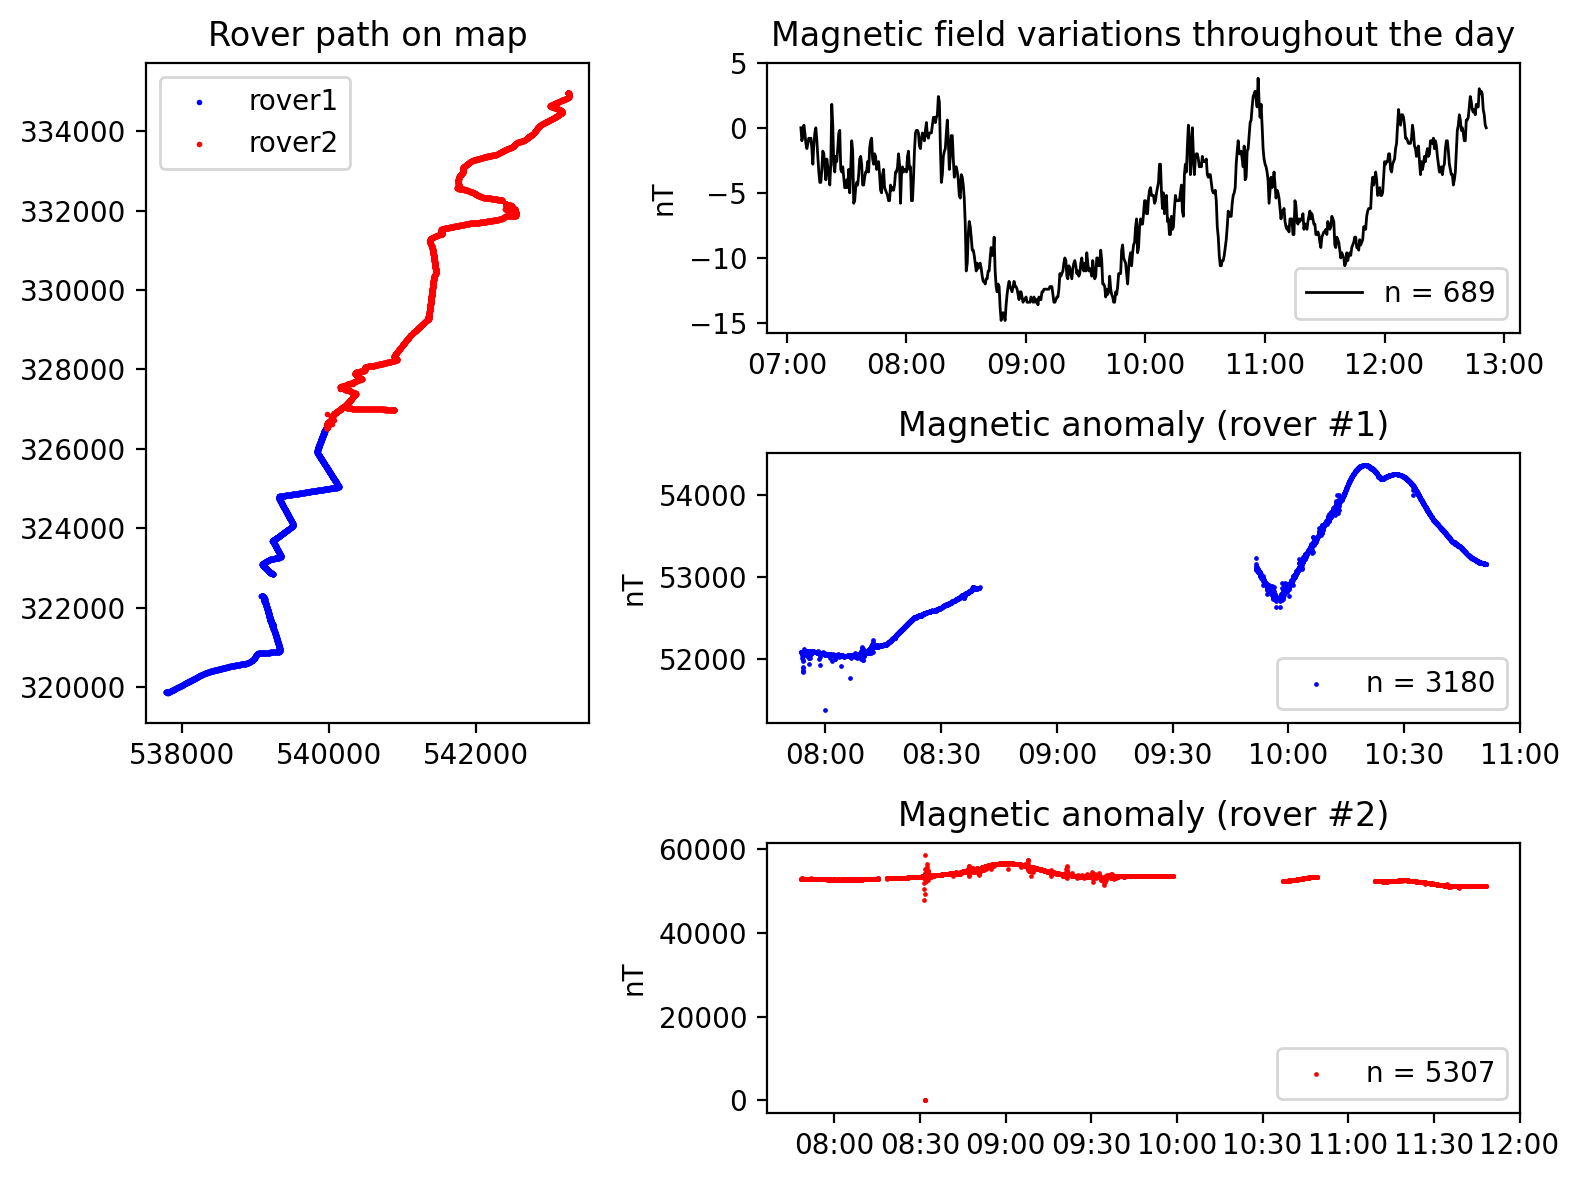

In [15]:
fig = plt.figure(figsize=(8, 6), dpi = 200)

ax1 = plt.subplot2grid((3, 5), (0, 0), rowspan=2, colspan=2)
ax2 = plt.subplot2grid((3, 5), (0, 2), colspan=3)
ax3 = plt.subplot2grid((3, 5), (1, 2), colspan=3)
ax4 = plt.subplot2grid((3, 5), (2, 2), colspan=3)

ax1.scatter(rover1["x"], rover1["y"], s=1, label="rover1", c="b")
ax1.scatter(rover2["x"], rover2["y"], s=1, label="rover2", c="r")
ax1.set_title(f"Rover path on map")
ax1.legend()

ax2.plot(base.time, base.nT, lw=1, label=f"n = {len(base["nT"])}", c="k")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.set_title("Magnetic field variations throughout the day")
ax2.set_ylabel("nT")
ax2.set_yticks([-15, -10, -5, 0, 5])
ax2.legend(loc="lower right")

ax3.scatter(rover1.time, rover1.nT, s=0.5, label=f"n = {len(rover1["nT"])}", c="b")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax3.set_ylabel("nT")
ax3.set_title("Magnetic anomaly (rover #1)")
ax3.legend(loc="lower right")

ax4.scatter(rover2.time, rover2.nT, s=0.5, label=f"n = {len(rover2["nT"])}", c="r")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax4.set_ylabel("nT")
ax4.set_title("Magnetic anomaly (rover #2)")
ax4.legend(loc="lower right")

plt.tight_layout()
plt.show()

### **Merge the two rover datasets into one**

In [175]:
rover = pd.concat([rover1, rover2], ignore_index=True)

### **Straigthen out the rover path (project onto a straight line)**

We use the Principal Component Analysis (PCA) instead of Linear Regression, because we need to project positions perpendicular to main direction.

In [176]:
rover = rover.dropna(subset=["x", "y", "nT"]).copy()
rover_coords = rover[["x", "y"]].values
pca = PCA(n_components=1)

# Fit a line
pca.fit(rover_coords)

# Project points on line
rover["distance"] = pca.transform(rover_coords)

# Get line direction and center
center = pca.mean_
direction = pca.components_[0]

# Generate line points
t = np.linspace(rover["distance"].min(), rover["distance"].max(), len(rover))
line_points = center + np.outer(t, direction)

# Project each point onto the fitted line (get 2D coordinates on the line)
projections = pca.transform(rover_coords)  # 1D distance along line
line_coords = pca.inverse_transform(projections)  # back to 2D x, y on the line

rover['x_line'] = line_coords[:, 0]
rover['y_line'] = line_coords[:, 1]

# Sort the measurements by distance
rover = rover.sort_values('distance').reset_index(drop=True)

# Because the first data points begin at the middle of the path, we need to restart the distance counter
rover["distance"] += np.abs(rover["distance"][0]).copy()



View the added `distance`, `x_line` and `y_line` column.

In [177]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line
0,57.020655,24.622575,51847.88,1900-01-01 07:54:12,537799.0,319857.0,0.000000,538196.669324,319733.295567
1,57.020662,24.622532,51842.78,1900-01-01 07:54:10,537796.0,319858.0,0.063765,538196.688265,319733.356455
2,57.020671,24.622497,51899.60,1900-01-01 07:54:08,537794.0,319859.0,0.424564,538196.795434,319733.700970
3,57.020661,24.622617,51847.65,1900-01-01 07:54:14,537801.0,319858.0,1.548935,538197.129410,319734.774594
4,57.020683,24.622467,51973.59,1900-01-01 07:54:06,537792.0,319861.0,1.740230,538197.186232,319734.957256
...,...,...,...,...,...,...,...,...,...
8478,57.155978,24.715039,51095.15,1900-01-01 11:44:22,543255.0,334976.0,16057.250142,542966.217037,335065.832759
8479,57.155977,24.715041,51093.85,1900-01-01 11:44:16,543255.0,334976.0,16057.250142,542966.217037,335065.832759
8480,57.155977,24.715043,51093.74,1900-01-01 11:44:34,543255.0,334976.0,16057.250142,542966.217037,335065.832759
8481,57.155981,24.715043,51094.23,1900-01-01 11:43:36,543255.0,334976.0,16057.250142,542966.217037,335065.832759


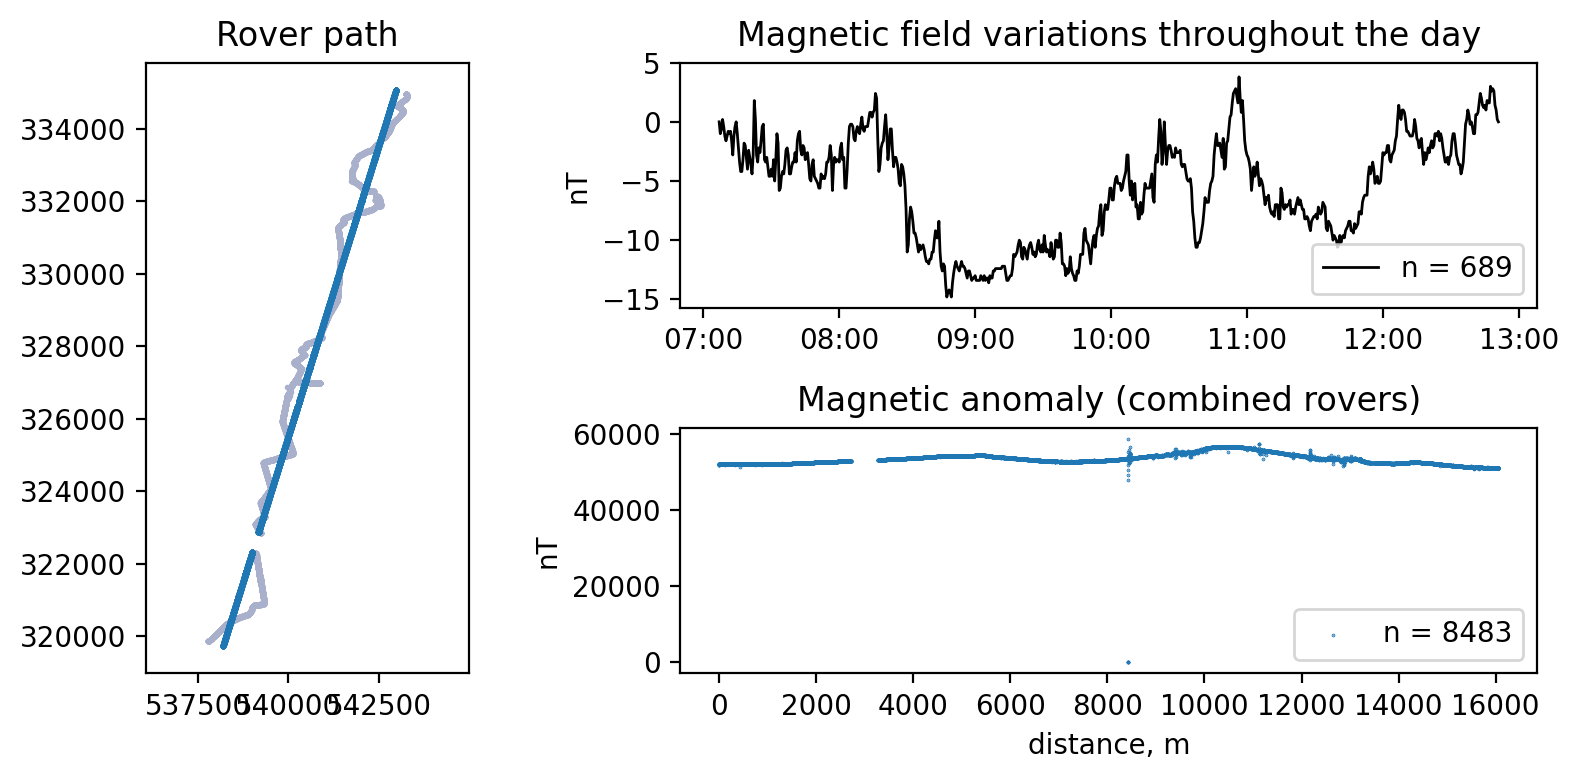

In [179]:
fig = plt.figure(figsize=(8, 4), dpi = 200)

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)
ax3 = plt.subplot2grid((2, 3), (1, 1), colspan=2)

ax1.scatter(rover["x"], rover["y"], s=1, label="original path", c="#A9B0CC")
ax1.scatter(rover["x_line"], rover["y_line"], s=1, label="line path")
ax1.set_title("Rover path")
ax1.axis("equal")

ax2.plot(base.time, base.nT, lw=1, label=f"n = {len(base["nT"])}", c="k")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.set_title("Magnetic field variations throughout the day")
ax2.set_ylabel("nT")
ax2.set_yticks([-15, -10, -5, 0, 5])
ax2.legend(loc="lower right")

ax3.scatter(rover.distance, rover.nT, s=0.1, label=f"n = {len(rover["nT"])}")
ax3.set_ylabel("nT")
ax3.set_xlabel("distance, m")
ax3.set_title("Magnetic anomaly (combined rovers)")
ax3.legend(loc="lower right")

plt.tight_layout()
plt.show()

### **Filtering**

#### **1. Diurnal correction**

Diurnal correction is important when surveying weak anomalies. Inčukalns anomaly is very intense, so the diurnal correction basically doesn't affect anything, but we will do it for the sake of process.

In [180]:
# Sort by time
base = base.sort_values('time')
rover = rover.sort_values('time')

# Interpolate base to rover timestamps using merge_asof + interpolation
# First, reindex base to include rover timestamps
combined_time = pd.concat([base['time'], rover['time']]).drop_duplicates().sort_values()

# Interpolate base magnetic readings to all timestamps
base_interp = base.set_index('time')['nT'].reindex(combined_time)
base_interp = base_interp.interpolate(method='time')

# Extract only rover timestamps
base_at_rover = base_interp.reindex(rover['time'])

# Subtract base variation from rover (diurnal correction)
base_reference = base['nT'].mean()  # or use first value as reference
rover['nT_corr'] = rover['nT'] - base_at_rover.values + base_reference


# Sort the measurements by distance
rover = rover.sort_values('distance').reset_index(drop=True)

View the added `nT_corr` column.

In [181]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr
0,57.020655,24.622575,51847.88,1900-01-01 07:54:12,537799.0,319857.0,0.000000,538196.669324,319733.295567,51846.318171
1,57.020662,24.622532,51842.78,1900-01-01 07:54:10,537796.0,319858.0,0.063765,538196.688265,319733.356455,51841.284838
2,57.020671,24.622497,51899.60,1900-01-01 07:54:08,537794.0,319859.0,0.424564,538196.795434,319733.700970,51898.171505
3,57.020661,24.622617,51847.65,1900-01-01 07:54:14,537801.0,319858.0,1.548935,538197.129410,319734.774594,51846.021505
4,57.020683,24.622467,51973.59,1900-01-01 07:54:06,537792.0,319861.0,1.740230,538197.186232,319734.957256,51972.228171
...,...,...,...,...,...,...,...,...,...,...
8478,57.155977,24.715043,51093.74,1900-01-01 11:44:34,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51096.864838
8479,57.155977,24.715043,51093.60,1900-01-01 11:44:32,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51096.744838
8480,57.155977,24.715044,51093.59,1900-01-01 11:44:30,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51096.748171
8481,57.155978,24.715043,51091.90,1900-01-01 11:44:08,543255.0,334976.0,16057.250142,542966.217037,335065.832759,51095.204838


#### **2. IGRF removal**

The International Geomagnetic Reference Field (IGRF) is the modelled Earth's main field (magnetic field generated in the outer core). We have to remove it to acquire the anomalous magnetic intensity. Although, the IGRF changes based on coordinates, we can apply a single value to all measurements, because, once again, Inčukalns anomaly is very intense.
Based on IGRF version 14, the mean field intensity in Inčukalns area is approximately `51980` nT.

In [182]:
rover["nT_corr"] = rover["nT_corr"] - 51980

View the updated `nT_corr` column.

In [183]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr
0,57.020655,24.622575,51847.88,1900-01-01 07:54:12,537799.0,319857.0,0.000000,538196.669324,319733.295567,-133.681829
1,57.020662,24.622532,51842.78,1900-01-01 07:54:10,537796.0,319858.0,0.063765,538196.688265,319733.356455,-138.715162
2,57.020671,24.622497,51899.60,1900-01-01 07:54:08,537794.0,319859.0,0.424564,538196.795434,319733.700970,-81.828495
3,57.020661,24.622617,51847.65,1900-01-01 07:54:14,537801.0,319858.0,1.548935,538197.129410,319734.774594,-133.978495
4,57.020683,24.622467,51973.59,1900-01-01 07:54:06,537792.0,319861.0,1.740230,538197.186232,319734.957256,-7.771829
...,...,...,...,...,...,...,...,...,...,...
8478,57.155977,24.715043,51093.74,1900-01-01 11:44:34,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-883.135162
8479,57.155977,24.715043,51093.60,1900-01-01 11:44:32,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-883.255162
8480,57.155977,24.715044,51093.59,1900-01-01 11:44:30,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-883.251829
8481,57.155978,24.715043,51091.90,1900-01-01 11:44:08,543255.0,334976.0,16057.250142,542966.217037,335065.832759,-884.795162


#### **3. Median filtering**

In [184]:
rover["nT_mf"] = rover["nT_corr"].rolling(window=100, center=True).median().copy()

# Remove data with NaN values due to median filtering
rover = rover[~np.isnan(rover["nT_mf"])]

View the added `nT_mf` column.

In [185]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr,nT_mf
50,57.021209,24.623766,52056.21,1900-01-01 07:55:20,537871.0,319920.0,81.543058,538220.890377,319811.158337,73.721505,99.708171
51,57.021227,24.623804,52035.08,1900-01-01 07:55:22,537873.0,319922.0,84.046860,538221.634091,319813.549134,52.564838,99.799838
52,57.021243,24.623844,52031.32,1900-01-01 07:55:24,537875.0,319924.0,86.550661,538222.377805,319815.939932,48.778171,99.991505
53,57.021259,24.623875,52034.51,1900-01-01 07:55:26,537877.0,319925.0,88.099596,538222.837891,319817.418958,51.941505,100.283171
54,57.021277,24.623907,52042.79,1900-01-01 07:55:28,537879.0,319927.0,90.603398,538223.581605,319819.809756,60.194838,100.753171
...,...,...,...,...,...,...,...,...,...,...,...
8429,57.155968,24.715045,51091.14,1900-01-01 11:46:28,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-885.321829,-885.425162
8430,57.155975,24.715035,51094.21,1900-01-01 11:47:24,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-882.611829,-885.425162
8431,57.155969,24.715035,51091.32,1900-01-01 11:45:12,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-885.941829,-885.425162
8432,57.155970,24.715036,51090.52,1900-01-01 11:45:08,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-886.741829,-885.425162


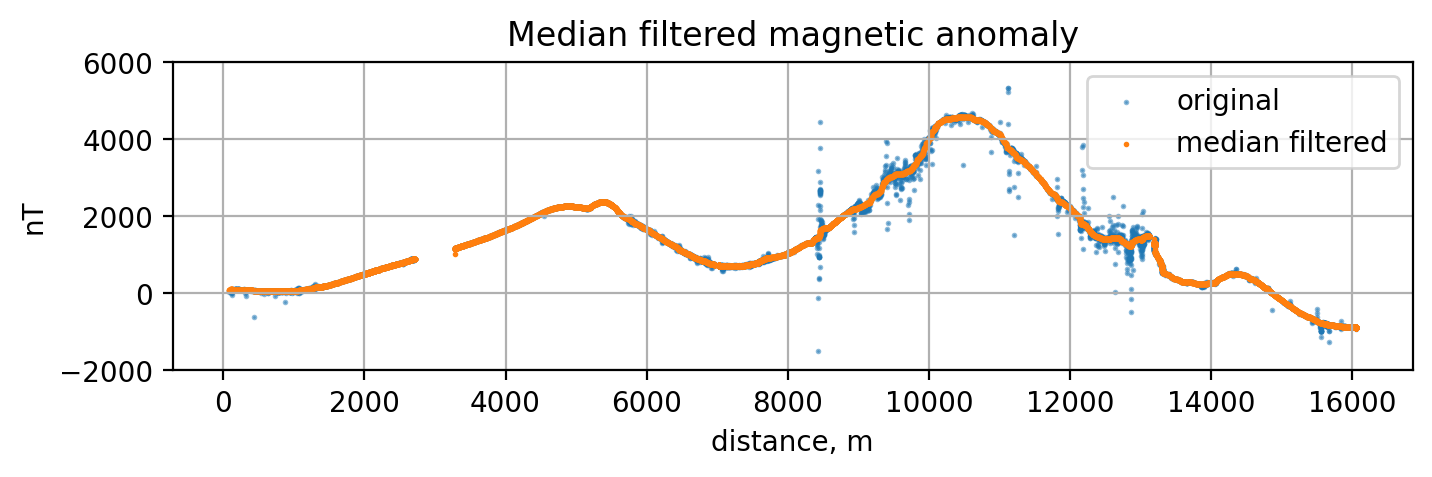

In [186]:
fig,ax = plt.subplots(figsize = (8, 2), dpi = 200, sharex=True)

ax.scatter(rover.distance, rover["nT_corr"], s=1, label=f"original", alpha = 0.5)
ax.scatter(rover.distance, rover["nT_mf"], s=1, label=f"median filtered")
ax.set_ylim(-2000, 6000)
ax.set_ylabel("nT")
ax.set_xlabel("distance, m")
ax.grid()
ax.set_title("Median filtered magnetic anomaly")
ax.legend(loc="upper right")

plt.show()

#### **4. Regional trend removal**

In [187]:
# Fit a 1st or 2nd degree polynomial
degree = 2  # 1 for linear, 2 for quadratic

coeffs = np.polyfit(rover['distance'], rover['nT_mf'], degree)
trend = np.polyval(coeffs, rover['distance'])

# Remove the trend
rover['nT_detrend'] = rover['nT_mf'] - trend

C:\Users\matiss-brants\AppData\Local\Temp\ipykernel_12728\240807087.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rover['nT_detrend'] = rover['nT_mf'] - trend


View the updated `nT_corr` column.

In [188]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr,nT_mf,nT_detrend
50,57.021209,24.623766,52056.21,1900-01-01 07:55:20,537871.0,319920.0,81.543058,538220.890377,319811.158337,73.721505,99.708171,718.603817
51,57.021227,24.623804,52035.08,1900-01-01 07:55:22,537873.0,319922.0,84.046860,538221.634091,319813.549134,52.564838,99.799838,717.024201
52,57.021243,24.623844,52031.32,1900-01-01 07:55:24,537875.0,319924.0,86.550661,538222.377805,319815.939932,48.778171,99.991505,715.545095
53,57.021259,24.623875,52034.51,1900-01-01 07:55:26,537877.0,319925.0,88.099596,538222.837891,319817.418958,51.941505,100.283171,714.803421
54,57.021277,24.623907,52042.79,1900-01-01 07:55:28,537879.0,319927.0,90.603398,538223.581605,319819.809756,60.194838,100.753171,713.603473
...,...,...,...,...,...,...,...,...,...,...,...,...
8429,57.155968,24.715045,51091.14,1900-01-01 11:46:28,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-885.321829,-885.425162,-560.718847
8430,57.155975,24.715035,51094.21,1900-01-01 11:47:24,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-882.611829,-885.425162,-560.718847
8431,57.155969,24.715035,51091.32,1900-01-01 11:45:12,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-885.941829,-885.425162,-560.718847
8432,57.155970,24.715036,51090.52,1900-01-01 11:45:08,543255.0,334975.0,16056.295275,542965.933409,335064.920988,-886.741829,-885.425162,-560.718847


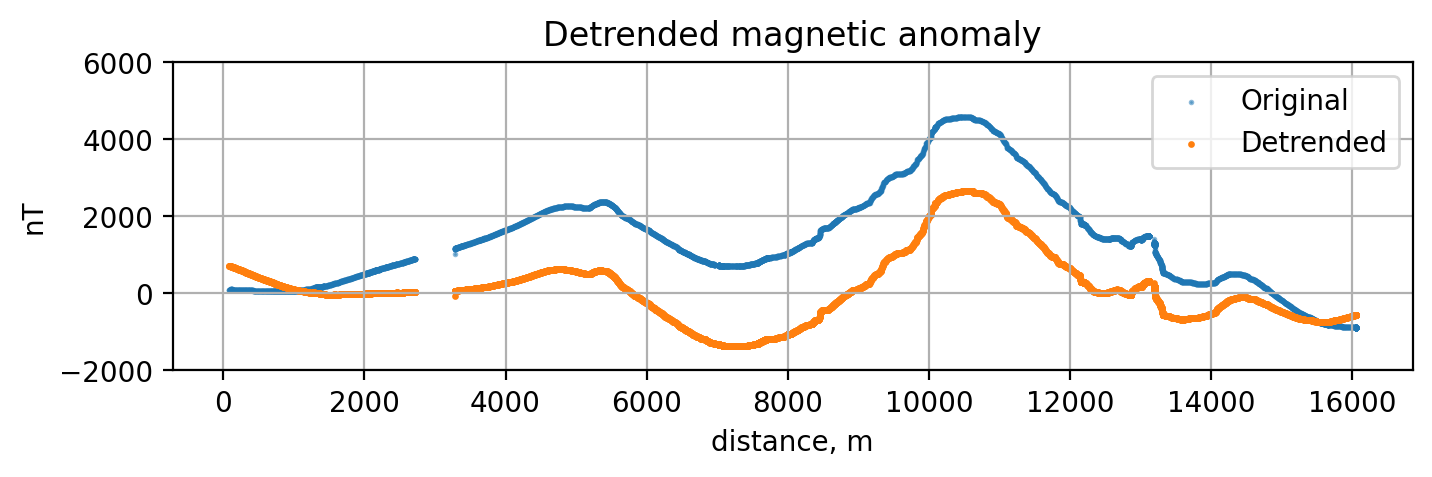

In [189]:
fig,ax = plt.subplots(figsize = (8, 2), dpi = 200, sharex=True)

ax.scatter(rover.distance, rover["nT_mf"], s=1, label=f"Original", alpha = 0.5)
ax.scatter(rover.distance, rover["nT_detrend"], s=2, label=f"Detrended")
# ax.set_ylim(np.min(rover["nT_mf"])*1.1, np.max(rover["nT_mf"])*1.1)
ax.set_ylim(-2000, 6000)

ax.set_ylabel("nT")
ax.set_xlabel("distance, m")
ax.grid()
ax.set_title("Detrended magnetic anomaly")
ax.legend(loc="upper right")

plt.show()

#### **5. Downsampling (reducing amount of data)**

In [190]:
# Leave only points after specified spacing distance
spacing = 150

first_point = [0]  # always keep first point
for i in range(1, len(rover)):
    if rover['distance'].iloc[i] - rover['distance'].iloc[first_point[-1]] >= spacing:
        first_point.append(i)
rover_full = rover.copy()
rover = rover.iloc[first_point].reset_index(drop=True)

In [191]:
rover

,latitude,longitude,nT,time,x,y,distance,x_line,y_line,nT_corr,nT_mf,nT_detrend
0,57.021209,24.623766,52056.21,1900-01-01 07:55:20,537871.0,319920.0,81.543058,538220.890377,319811.158337,73.721505,99.708171,718.603817
1,57.022273,24.625818,52081.59,1900-01-01 07:57:20,537994.0,320039.0,231.707393,538265.494276,319954.545295,100.481505,97.553171,617.115515
2,57.023350,24.627844,52077.78,1900-01-01 07:59:18,538116.0,320160.0,383.484429,538310.577202,320099.472167,95.318171,81.084838,502.109438
3,57.024426,24.629880,52054.52,1900-01-01 08:01:12,538238.0,320281.0,535.261464,538355.660127,320244.399039,71.078171,67.443171,391.802328
4,57.025405,24.632346,52046.85,1900-01-01 08:03:14,538387.0,320392.0,685.509745,538400.288961,320387.866155,66.201505,62.821505,293.332976
...,...,...,...,...,...,...,...,...,...,...,...,...
98,57.150250,24.711636,51356.04,1900-01-01 11:33:06,543056.0,334336.0,15387.025558,542767.137611,334425.857466,-622.101829,-616.470162,-695.715000
99,57.151362,24.713376,51186.19,1900-01-01 11:35:02,543160.0,334461.0,15537.275451,542811.766924,334569.326121,-790.531829,-756.560162,-748.287734
100,57.153190,24.711117,51156.14,1900-01-01 11:38:54,543021.0,334663.0,15688.870858,542856.795900,334714.079562,-819.781829,-827.496829,-729.063869
101,57.154198,24.713473,51041.72,1900-01-01 11:40:52,543162.0,334777.0,15839.607469,542901.569784,334858.012968,-934.048495,-857.111829,-667.177121


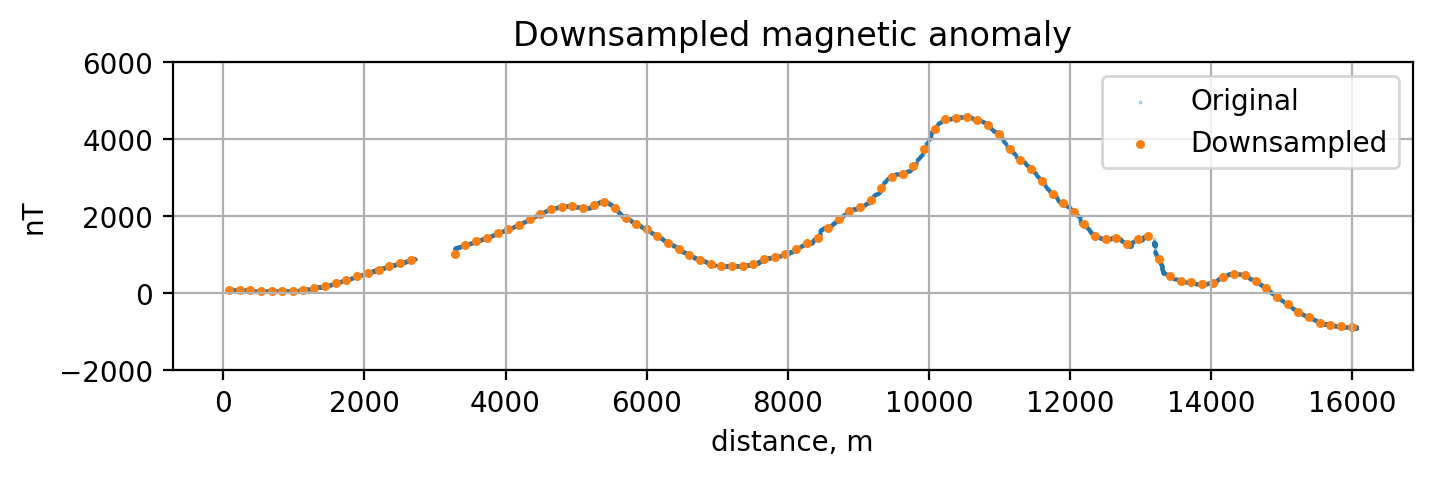

In [192]:
fig,ax = plt.subplots(figsize = (8, 2), dpi = 200, sharex=True)

ax.scatter(rover_full.distance, rover_full["nT_mf"], s=0.1, label=f"Original", alpha = 0.5)
ax.scatter(rover.distance, rover["nT_mf"], s=5, label=f"Downsampled")
ax.set_ylim(-2000, 6000)
ax.set_ylabel("nT")
ax.set_xlabel("distance, m")
ax.grid()
ax.set_title("Downsampled magnetic anomaly")
ax.legend(loc="upper right")

plt.show()

### **Final data**

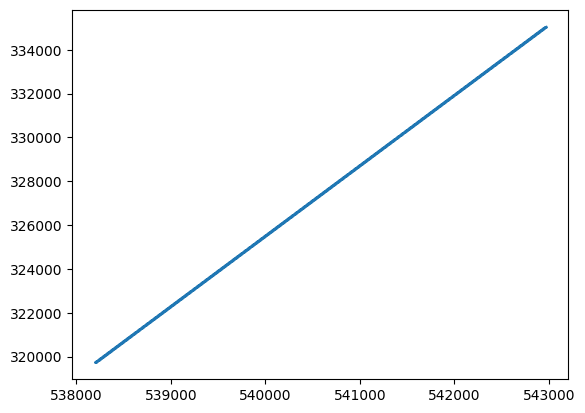

In [193]:
plt.scatter(line_points[:,0], line_points[:, 1], s=0.1)

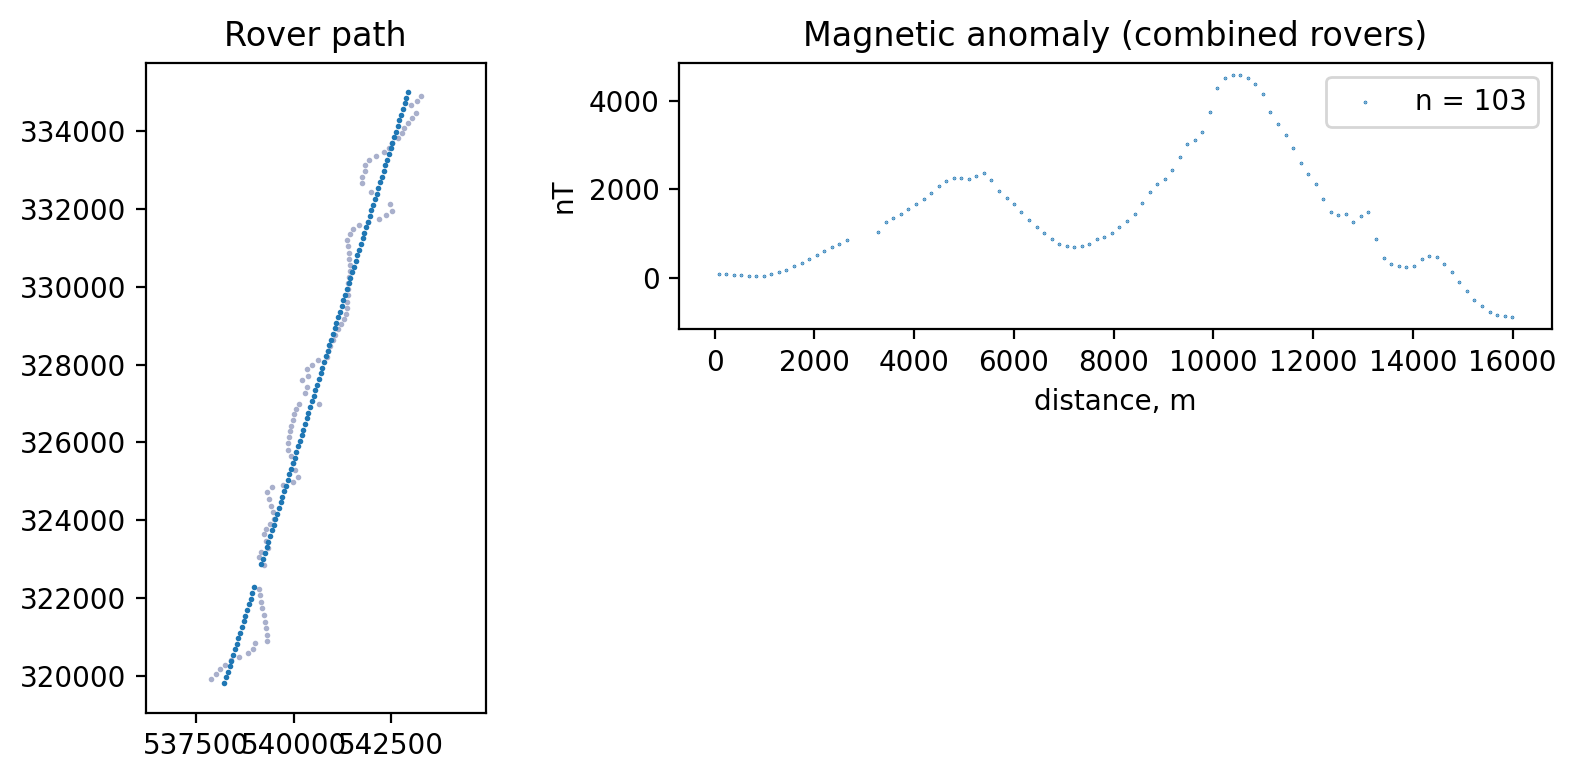

In [200]:
fig = plt.figure(figsize=(8, 4), dpi = 200)

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)

ax1.scatter(rover["x"], rover["y"], s=1, c="#A9B0CC")
ax1.scatter(rover["x_line"], rover["y_line"], s=1)
ax1.set_title("Rover path")
ax1.axis("equal")

ax2.scatter(rover["distance"], rover["nT_mf"], s=0.1, label=f"n = {len(rover["nT"])}")
ax2.set_ylabel("nT")
ax2.set_xlabel("distance, m")
ax2.set_title("Magnetic anomaly (combined rovers)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Modelling the ore body

**Keywords:** total magnetic intensity, forward simulation, integral formulation, tensor mesh.

</br>

**Summary:** Here we use the module [simpeg.potential_fields.magnetics](xref:simpeg#simpeg.potential_fields.magnetics) to simulate total magnetic intensity data for a synthetic susceptibility model. We use the [3D integral formulation](xref:simpeg#simpeg.potential_fields.magnetics.Simulation3DIntegral) and carry out the forward simulation on a tensor mesh. The integral formulation works well when magnetic susceptibilities are less than 0.1 SI. However when susceptibilities are sufficiently large, self-demagnetization becomes significant and the integral formulation is no longer accurate.

</br>

**Learning Objectives:**

- How to simulate magnetic data for 3D structures with SimPEG.
- How to create magnetics surveys.
- How to design tensor meshes for magnetic simulations using the integral formulation.
- How to predict total magnetic intensity data for a susceptibility model.
- How to include surface topography in the forward simulation.
- What are the units of the susceptibility model and resulting data.

## Import Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to simulating magnetic data are imported from [simpeg.potential_fields.magnetics](xref:simpeg#simpeg.potential_fields.magnetics).
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils). To simulate magnetic data, we need to define our problem geometry on a numerical grid (or mesh).
To generate the mesh, we used the [discretize](https://discretize.simpeg.xyz/en/main) package.

In [201]:
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# mpl.rcParams.update({"font.size": 14})

save_output = False  # Optional

## Define the Topography

Surface topography is defined as an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray) for 3D simulations.
Here, we create basic topography for the forward simulation.
For user-specific simulations, you may load topography from an XYZ file.

In [207]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-2000, 20000, 82), np.linspace(-2000, 20000, 82))
rng = np.random.default_rng(seed=737)
z_topo = 100 * np.ones(x_topo.shape)

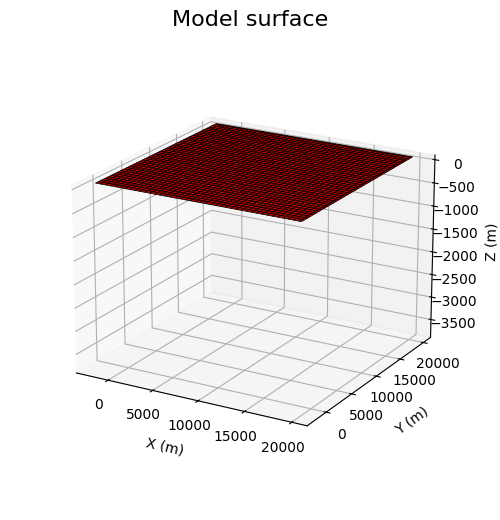

In [213]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([z_topo.max() - 4000, z_topo.max()])
ax.plot_surface(x_topo, y_topo, z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Model surface", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

In [214]:
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo]

## Define the Survey

Surveys within SimPEG generally require the user to create and connect three types of objects:

- [receivers](xref:simpeg#simpeg.potential_fields.magnetics.receivers.Point): which define the locations of field measurements and type of data being measured.
- [sources](xref:simpeg#simpeg.potential_fields.magnetics.sources.UniformBackgroundField): the passive or active sources responsible for generating geophysical responses, and their associated receivers.
- [survey](xref:simpeg#simpeg.potential_fields.magnetics.Survey): the object which stores and organizes all of the sources and receivers.

Here, we define the survey that will be used for the forward simulation. Magnetic surveys are simple to create. The user only needs an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray) to define the xyz locations of the observation locations, the field components being measured, and the Earth's inducing field. For the tutorial simulation, the receivers are located 10 m above the surface topography and spaced 10 m apart.

In [215]:
# Define the observation locations as an (N, 3) numpy array or load them.
x = np.linspace(0, 16000, 103)
y = np.linspace(0, 16000, 103)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
# Interpolates the survey data
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 10  # Flight height 10 m above surface.
receiver_locations = np.c_[x, y, z]

In [216]:
# Define the component(s) of the field we want to simulate as a list of strings.
# Here we simulation total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]

# Define the inducing field
inclination = 72  # inclination [deg]
declination = 15  # declination [deg]
amplitude = 51980  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

If desired, we can extract various objects and properties from the objects used to generate the survey. E.g.

In [217]:
print("# of data: {}".format(survey.nD))  # number of data that will be simulated
print(survey.source_field.inclination)  # inclination of the source field
print(survey.source_field.receiver_list[0])  # the receiver object
print(receiver_list[0].locations[:5, :])  # the first 5 receiver locations

# of data: 10609
72.0
[[  0.           0.         110.        ]
 [156.8627451    0.         110.        ]
 [313.7254902    0.         110.        ]
 [470.58823529   0.         110.        ]
 [627.45098039   0.         110.        ]]


## Design a (Tensor) Mesh

Meshes are designed using the [discretize](https://discretize.simpeg.xyz/en/main) package. See the [discretize user tutorials](https://discretize.simpeg.xyz/en/main/tutorials/mesh_generation/index.html) to learn more about creating meshes.
Here, the forward simulation is computed for a [tensor mesh](xref:discretize#discretize.TensorMesh). If you wanted to generate a [tree mesh](xref:discretize#discretize.TreeMesh) instead, you can use the code snippet from the [Forward simulation of magnetic gradiometry data](fwd_magnetics_gradiometry_3d.ipynb) tutorial.

The integral formulation for magnetics essentially sums the independent contribution for every magnetized voxel cell in the mesh. Since the kernel function that computes the contribution for a single cell is an analytic solution, small cells are not required to accurately compute the contributions from coarse structures with constant magnetization (e.g. a rectangular prism). For complex structures however, or to define surface topography more accurately, finer cells may be needed. Furthermore, cells do not need to be cubic. **Since the analytic solution is only valid outside the magnetized region, please do no place receivers within the Earth.**

Here, a core cell width of 5 m is used within our survey region. Padding is used to extend the mesh outside the immediate survey area. The mesh will be plotted after we define our density contrast model.

In [218]:
# Generate tensor mesh with top at z = 0 m
dh = 200.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)] # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)] # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
hz = [(dh, 5, -1.3), (dh, 15)]  # Cells which are defined. 5 padded elongated, 40 normal, 5 padded elongated
mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
mesh.origin += np.r_[0.0, 0.0, z_topo.max()]

If desired, we can extract various properties of the mesh. E.g.

In [219]:
print("# of cells: {}".format(mesh.n_cells))  # Number of cells
print("# of x-faces: {}".format(mesh.n_faces_x))  # Number of x-faces
print("Origin: {}".format(mesh.origin))  # bottom-southewest corner
print("Max cell volume: {}".format(mesh.cell_volumes.max()))  # Largest cell size
print(mesh.cell_centers[0:5, :])  # Cell center locations

# of cells: 50000
# of x-faces: 51000
Origin: [-6351.206 -6351.206 -5251.206]
Max cell volume: 409487144.1127263
[[-5979.913 -5979.913 -4879.913]
 [-5323.01  -5979.913 -4879.913]
 [-4817.7   -5979.913 -4879.913]
 [-4429.    -5979.913 -4879.913]
 [-4130.    -5979.913 -4879.913]]


## Define the Active Cells

Whereas cells below the Earth's surface contribute towards the simulated magnetic anomaly, air cells do not. 
The set of mesh cells used in the forward simulation are referred to as 'active cells'. Unused cells (air cells) are 'inactive cells'. Here, the discretize [active_from_xyz](xref:discretize#discretize.utils.active_from_xyz) utility function is used to find the indices of the active cells using the mesh and surface topography. The output quantity is a ``bool`` array.

In [220]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz) # Substracts the active cells from above ground to below ground

## Mapping from the Model to Active Cells

In SimPEG, the term 'model' is not synonymous with the physical property values defined on the mesh. For example, the model may be defined as the logarithms of the physical property values, or be parameters defining a layered Earth. When simulating total magnetic intensity data using the integral formulation, we must define a mapping from the set of model parameters to the active cells in the mesh. Mappings are created using the [simpeg.maps](xref:simpeg#simpeg.maps.IdentityMap) module. For the tutorial exercise, the model is the susceptibility values for all active cells. As such, our mapping is an identity mapping, whose dimensions are equal to the number of active cells.

In [221]:
# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active)

## Define the Model

Here, we create the model that will be used to predict total magnetic intensity data.
Recall that our model is the susceptibility values for all active mesh cells.
So the model is a 1D [numpy.ndarray](xref:numpy#numpy.ndarray) whose length is
equal to the number of model parameters.
**In SimPEG, susceptibility values are in SI units**.
Here, the model consists of a susceptible sphere within a negligibly susceptible host.
We plot the model using the [plot_slice](xref:discretize#discretize.TensorMesh.plot_slice) method.

In [222]:
# Define susceptibility values for each unit in SI
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

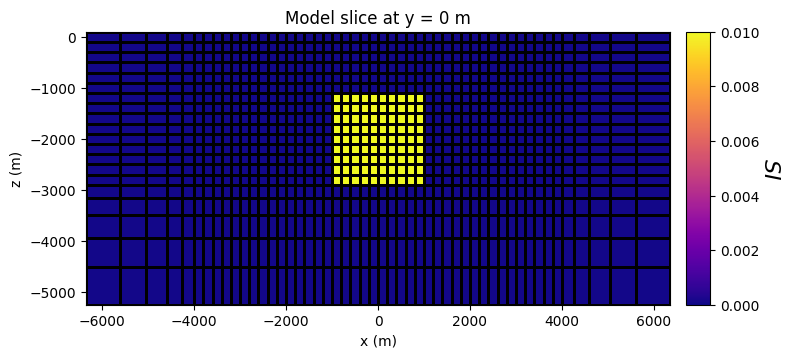

In [223]:
# Instantiate a vector array. Models in SimPEG are vector arrays.
model = background_susceptibility * np.ones(n_active)

# You can use SimPEG utilities to add structures to the model more concisely,
# or index the mesh cells manually.

# Add polygon defined by set of points. Have to be in this specific order
# xp = np.kron(np.ones((2)), [-30, 50, 50, -20]) # X dimension
# yp = np.kron([-500, 500], np.ones((4))) # The limits for Y dimension
# zp = np.kron(np.ones((2)), [-30, -30, 100, 100])
xp = np.kron(np.ones((2)), [-1000, 1000, -1000, 1000]) # X dimension
yp = np.kron([-1000, 1000], np.ones((4))) # The limits for Y dimension
zp = np.kron(np.ones((2)), [-3000, -3000, -1000, -1000])
poly_points = np.c_[mkvc(xp), mkvc(yp), mkvc(zp)] # Z dimension

# Calculate the dyke extent in y dimension too, so the whole model space is covered with it
ind_poly = model_builder.get_indices_polygon(mesh, poly_points)
ind_poly = ind_poly[active_cells]
model[ind_poly] = sphere_susceptibility

# Mapping to ignore inactive cells when plotting model
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

# Plot Susceptibility Model
fig = plt.figure(figsize=(8, 3.5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(model))
mesh.plot_slice(
    plotting_map * model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)
plt.show()

## Define the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class.
In this case, we use the simulation class for the [3D integral formulation](xref:simpeg#simpeg.potential_fields.magnetics.Simulation3DIntegral). To fully define the forward simulation, we need to connect the simulation object to:

- the survey
- the mesh
- the indices of the active cells
- the mapping from the model to the active cells
- the model type: "scalar" for susceptibility model, "vector" for magnetic vector model

This is accomplished by setting each one of the aforementioned items as a property of the simulation object. Additional keyword arguments can also be set which impact the forward simulation. Because we are only simulating data for a single model, there is no benefit to storing the sensitivities for the forward simulation. ``store_sensitivities`` property to *'forward_only'*

> By choosing `engine="choclo"` we can make our simulation to run the faster and more memory efficient implementation of the magnetic forward that uses [Numba](https://numba.pydata.org/) and [Choclo](https://www.fatiando.org/choclo) under the hood. To do so, we need to have [Choclo installed](https://www.fatiando.org/choclo/latest/install.html).

In [224]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

## Simulate Total Magnetic Intensity Data

Once any simulation within SimPEG has been properly constructed, simulated data for a given model vector can be computed using the [dpred](xref:simpeg#simpeg.simulation.BaseSimulation.dpred) method. In SimPEG, total magnetic data values are in **units nT.**

In [225]:
dpred = simulation.dpred(model)

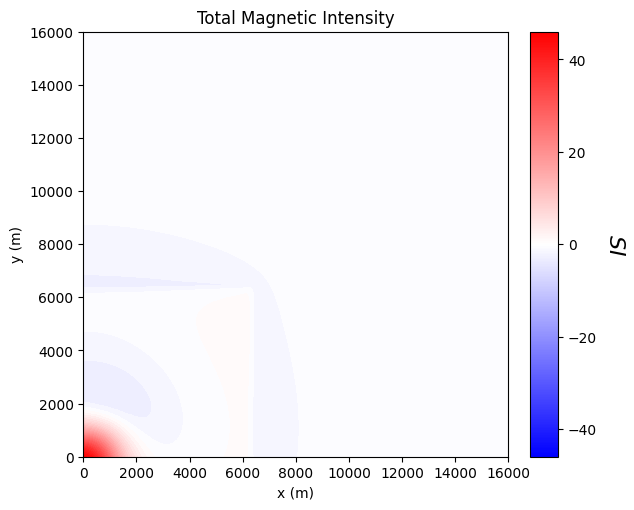

In [226]:
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dpred)), vmax=np.max(np.abs(dpred)))
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Total Magnetic Intensity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$SI$", rotation=270, labelpad=20, size=16)

plt.show()

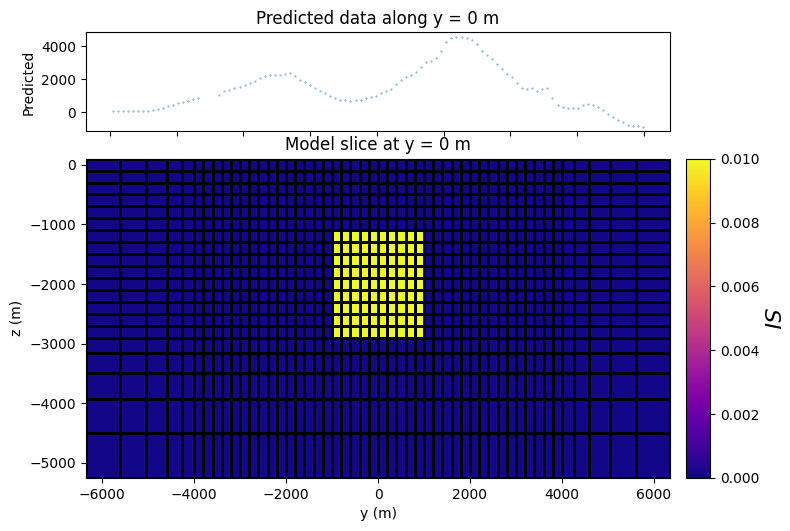

In [230]:
calc_mag = np.column_stack([receiver_list[0].locations, dpred])
prof_pred = calc_mag[calc_mag[:, 1] == 0]  # Get receiver values over the X axis

# Plot them on susceptibility model
fig = plt.figure(figsize=(8, 5.5))

# Top plot
ax0 = fig.add_axes([0.1, 0.75, 0.73, 0.18])
ax0.scatter(rover["distance"], rover["nT_mf"], s=0.1, label=f"n = {len(rover["nT"])}")
ax0.set_ylabel("Predicted")
ax0.set_xticklabels([])
ax0.set_title("Predicted data along y = 0 m")

# Main model slice
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.58])

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(model))
mesh.plot_slice(
    plotting_map * model,
    normal="X",
    ax=ax1,
    ind=int(mesh.shape_cells[0] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)

ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("y (m)")
ax1.set_ylabel("z (m)")

# Colorbar
ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.58])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

**Optional:** Export the data and topography

In [ ]:
if save_output:
    dir_path = os.path.sep.join([".", "fwd_magnetics_induced_3d_outputs"]) + os.path.sep
    if not os.path.exists(dir_path):
        os.mkdir(dir_path)

    fname = dir_path + "magnetics_topo.txt"
    np.savetxt(fname, np.c_[topo_xyz], fmt="%.4e")

    rng = np.random.default_rng(seed=211)
    maximum_anomaly = np.max(np.abs(dpred))
    noise = rng.normal(scale=0.02 * maximum_anomaly, size=len(dpred))
    fname = dir_path + "magnetics_data.obs"
    np.savetxt(fname, np.c_[receiver_locations, dpred + noise], fmt="%.4e")

## Calculating the ore body volume

Using our model and aeromagnetic map